# Load, Preprocess, Clean

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'svg'

In [40]:
dyn_heap = pd.read_csv('data/final-run/time_dynamic_stepping_path_oheap.csv')
dyn_map = pd.read_csv('data/final-run/time_dynamic_stepping_path_omap.csv')
dyn_ram = pd.read_csv('data/final-run/time_dynamic_stepping_path_oram.csv')
stt_heap = pd.read_csv('data/final-run/time_static_path_oheap.csv')
stt_map = pd.read_csv('data/final-run/time_static_path_omap.csv')
stt_ram = pd.read_csv('data/final-run/time_static_path_oram-4.csv')

all_data = [dyn_heap, dyn_map, dyn_ram, stt_heap, stt_map, stt_ram]

In [41]:
for x in all_data:
    x['n'] = 2 ** x['n']

In [42]:

rat = stt_ram['init'] / stt_ram['alloc']
rat.min(), rat.max()

(12.339759284024277, 3132079.2408856335)

In [43]:
alln = np.arange(1, (2**24)+1, dtype=np.uint64)
np2_arr = (2 ** (np.ceil(np.log2(alln)))).astype(np.uint64)

naiver = pd.DataFrame(alln, columns=['n'])
naiver['np2'] = np2_arr
p2s = naiver['n'] == naiver['np2']
naiver['isp2'] = 0
naiver['isp2'][p2s] = 1

/var/folders/vp/c_37y0_x1tb48ny75yll2nw40000gq/T/ipykernel_84293/2187952654.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naiver['isp2'][p2s] = 1


In [44]:
def grow_naive_ram(df):
    df_copy = df.copy(deep=True)
    res = (pd.merge(naiver, df_copy, left_on='np2', right_on='n', suffixes=('', '_temp'))
           .drop(columns=['n_temp']))
    
    for col in filter(lambda x: x.startswith('insert'), res.columns):
        # 1.5 for download of prev ods and upload of new one.
        res[col] = res[col] + (res['isp2'] * (1.5*res['init'+ col[6:]]))# + (res['n'] * res[col])))
    
    return res

naive_ram = grow_naive_ram(stt_ram)
all_data.append(naive_ram)

In [45]:
def grow_naive_others(df):
    df_copy = df.copy(deep=True)
    res = (pd.merge(naiver, df_copy, left_on='np2', right_on='n', suffixes=('', '_temp'))
           .drop(columns=['n_temp']))
    
    for col in filter(lambda x: x.startswith('insert'), res.columns):
        # 1.5 for download of prev ods and upload of new one.
        res[col] = res[col] + (res['isp2'] * (1.5*naive_ram['init'+ col[6:]]))# + (res['n'] * res[col])))
    
    return res

naive_map = grow_naive_others(stt_map)
all_data.append(naive_map)
naive_heap = grow_naive_others(stt_heap)
all_data.append(naive_heap)

In [46]:
def simple_grow(df):
    df_copy = df.copy(deep=True)
    return (pd.merge(naiver, df_copy, left_on='np2', right_on='n', suffixes=('', '_temp'))
            .drop(columns=['n_temp']))

In [47]:
latency = 2e-4 # seconds
bandwidth = 10 * (1 << 27) # 10Gbps = 1.25 GBps

def networked(df, act):
    # Assuming the bandwidth doesn't become a bottleneck
    return df[act] + (latency * df[act+'_accesses']) + (df[act+'_bytes'] / bandwidth)

def networked_insert(df):
    return networked(df, 'insert')

def networked_delete(df):
    return networked(df, 'delete')

In [48]:
cutoff = 1 << 7
def gte_cutoff(df):
    return df[df['n'] >= cutoff]

In [49]:
dyn_heap = gte_cutoff(dyn_heap)
dyn_map = gte_cutoff(dyn_map)
dyn_ram = gte_cutoff(dyn_ram)
stt_heap = gte_cutoff(stt_heap)
stt_map = gte_cutoff(stt_map)
stt_ram = gte_cutoff(stt_ram)
naive_ram = gte_cutoff(naive_ram)
naive_map = gte_cutoff(naive_map)
naive_heap = gte_cutoff(naive_heap)

# Plots

### RAM

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


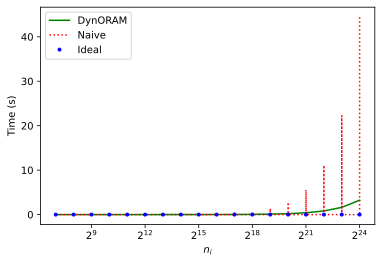

In [54]:
plt.plot(dyn_ram['n'], networked_insert(dyn_ram), label='DynORAM', linestyle='-', color='green')
plt.plot(naive_ram['n'], networked_insert(naive_ram), label='Naive', linestyle=':', color='red')
plt.plot(stt_ram['n'], networked_insert(stt_ram), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynoram_insert.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


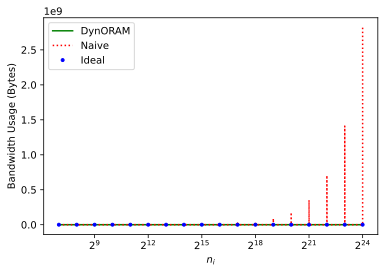

In [55]:
plt.plot(dyn_ram['n'], dyn_ram['insert_bytes'], label='DynORAM', linestyle='-', color='green')
plt.plot(naive_ram['n'], naive_ram['insert_bytes'], label='Naive', linestyle=':', color='red')
plt.plot(stt_ram['n'], stt_ram['insert_bytes'], label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Bandwidth Usage (Bytes)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynoram_insert_bytes.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


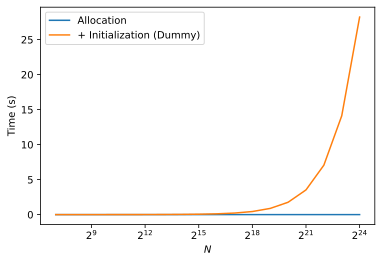

In [57]:
plt.plot(stt_ram['n'], stt_ram['alloc'], label='Allocation')
plt.plot(stt_ram['n'], stt_ram['init'], label='+ Initialization (Dummy)')
# plt.plot(stt_ram['n'], stt_ram['n'] * networked_insert(stt_ram), label='$N$ Insertions')

plt.xlabel('$N$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
plt.savefig('plots/final/oram_alloc-init-fill.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


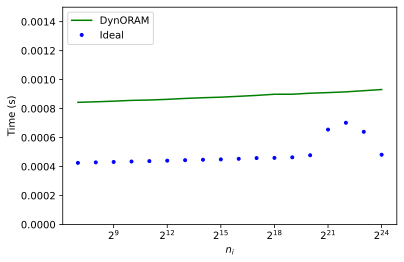

In [56]:
plt.plot(dyn_ram['n'], networked_delete(dyn_ram), label='DynORAM', linestyle='-', color='green')
plt.plot(stt_ram['n'], networked_delete(stt_ram), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.ylim(0.0, 0.0015)
# plt.yscale('log')
plt.legend(loc='upper left')
plt.savefig('plots/final/dynoram_delete.eps')
plt.show()

### Map

In [125]:
print('Insertion Time')
# print(networked_insert(naive_map).iloc[0], networked_insert(naive_map).iloc[-1])
# print(networked_insert(dyn_map).iloc[0], networked_insert(dyn_map).iloc[-1])
# print(networked_insert(stt_map).iloc[0], networked_insert(stt_map).iloc[-1])

print(f'{networked_insert(naive_map).iloc[0] / networked_insert(stt_map).iloc[0]}'
     f'-{networked_insert(naive_map).iloc[-1] / networked_insert(stt_map).iloc[-1]}')
print(f'{networked_insert(dyn_map).iloc[0] / networked_insert(stt_map).iloc[0]}'
     f'-{networked_insert(dyn_map).iloc[-1] / networked_insert(stt_map).iloc[-1]}')

print()
print('Insertion Bandwidth Usage')
# print(naive_map['insert_bytes'].iloc[0], naive_map['insert_bytes'].iloc[-1])
# print(dyn_map['insert_bytes'].iloc[0], dyn_map['insert_bytes'].iloc[-1])
# print(stt_map['insert_bytes'].iloc[0], stt_map['insert_bytes'].iloc[-1])

print(f'{naive_map["insert_bytes"].iloc[0] / stt_map["insert_bytes"].iloc[0]}'
     f'-{naive_map["insert_bytes"].iloc[-1] / stt_map["insert_bytes"].iloc[-1]}')
print(f'{dyn_map["insert_bytes"].iloc[0] / stt_map["insert_bytes"].iloc[0]}'
     f'-{dyn_map["insert_bytes"].iloc[-1] / stt_map["insert_bytes"].iloc[-1]}')

Insertion Time
1.0247206714618136-14.774961174795694
4.5476051439826035-1.9416990479052119

Insertion Bandwidth Usage
1.1181761786600497-1358.2543569711538
5.161290322580645-4.326923076923077


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


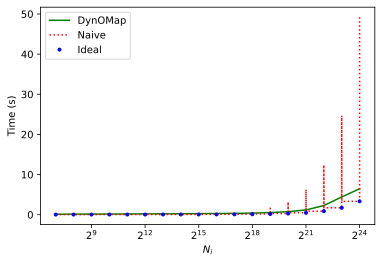

In [14]:
plt.plot(dyn_map['n'], networked_insert(dyn_map), label='DynOMap', linestyle='-', color='green')
plt.plot(naive_map['n'], networked_insert(naive_map), label='Naive', linestyle=':', color='red')
plt.plot(stt_map['n'], networked_insert(stt_map), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynomap_insert.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


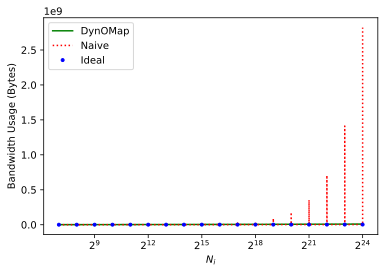

In [15]:
plt.plot(dyn_map['n'], dyn_map['insert_bytes'], label='DynOMap', linestyle='-', color='green')
plt.plot(naive_map['n'], naive_map['insert_bytes'], label='Naive', linestyle=':', color='red')
plt.plot(stt_map['n'], stt_map['insert_bytes'], label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Bandwidth Usage (Bytes)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynomap_insert_bytes.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


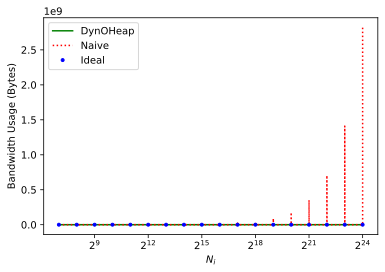

In [37]:
plt.plot(dyn_heap['n'], dyn_heap['insert_bytes'], label='DynOHeap', linestyle='-', color='green')
plt.plot(naive_heap['n'], naive_heap['insert_bytes'], label='Naive', linestyle=':', color='red')
plt.plot(stt_heap['n'], stt_heap['insert_bytes'], label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Bandwidth Usage (Bytes)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynoheap_insert_bytes.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


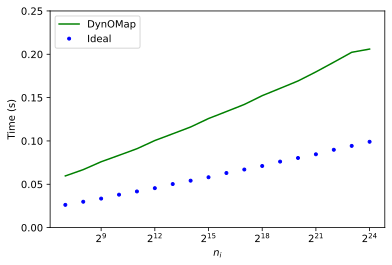

In [128]:
plt.plot(dyn_map['n'], networked_delete(dyn_map), label='DynOMap', linestyle='-', color='green')
plt.plot(stt_map['n'], networked_delete(stt_map), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.ylim(0.0, 0.25)
# plt.yscale('log')
plt.legend(loc='upper left')
plt.savefig('plots/final/dynomap_delete.eps')
plt.show()

In [35]:
dyn_map

,n,alloc,insert,insert_accesses,insert_bytes,delete,delete_accesses,delete_bytes
6,128,0.000024,0.006415,560,931840,0.003285,280,465920
7,256,0.000047,0.007958,624,1168128,0.004051,312,584064
8,512,0.000096,0.009929,704,1464320,0.005030,352,732160
9,1024,0.000205,0.011965,768,1757184,0.005978,384,878592
10,2048,0.000413,0.014441,832,2076672,0.007044,416,1038336
11,4096,0.000804,0.017793,912,2466048,0.008358,456,1233024
12,8192,0.001617,0.021711,976,2842112,0.009593,488,1421056
13,16384,0.003168,0.027160,1040,3244800,0.010893,520,1622400
14,32768,0.006354,0.036214,1120,3727360,0.012469,560,1863680
15,65536,0.012947,0.051000,1184,4186624,0.013963,592,2093312


### Heap

In [124]:
print('Insertion Time')
# print(networked_insert(naive_heap).iloc[0], networked_insert(naive_heap).iloc[-1])
# print(networked_insert(dyn_heap).iloc[0], networked_insert(dyn_heap).iloc[-1])
# print(networked_insert(stt_heap).iloc[0], networked_insert(stt_heap).iloc[-1])

print(f'{networked_insert(naive_heap).iloc[0] / networked_insert(stt_heap).iloc[0]}'
     f'-{networked_insert(naive_heap).iloc[-1] / networked_insert(stt_heap).iloc[-1]}')
print(f'{networked_insert(dyn_heap).iloc[0] / networked_insert(stt_heap).iloc[0]}'
     f'-{networked_insert(dyn_heap).iloc[-1] / networked_insert(stt_heap).iloc[-1]}')

print()
print('Insertion Bandwidth Usage')
# print(naive_heap['insert_bytes'].iloc[0], naive_heap['insert_bytes'].iloc[-1])
# print(dyn_heap['insert_bytes'].iloc[0], dyn_heap['insert_bytes'].iloc[-1])
# print(stt_heap['insert_bytes'].iloc[0], stt_heap['insert_bytes'].iloc[-1])

print(f'{naive_heap["insert_bytes"].iloc[0] / stt_heap["insert_bytes"].iloc[0]}'
     f'-{naive_heap["insert_bytes"].iloc[-1] / stt_heap["insert_bytes"].iloc[-1]}')
print(f'{dyn_heap["insert_bytes"].iloc[0] / stt_heap["insert_bytes"].iloc[0]}'
     f'-{dyn_heap["insert_bytes"].iloc[-1] / stt_heap["insert_bytes"].iloc[-1]}')

Insertion Time
1.6149334803534694-14.051990500470364
5.063909759567975-1.8513632336848824

Insertion Bandwidth Usage
5.053191489361702-168899.13758389262
5.638297872340425-5.201342281879195


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


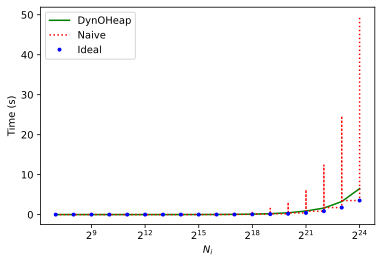

In [17]:
plt.plot(dyn_heap['n'], networked_insert(dyn_heap), label='DynOHeap', linestyle='-', color='green')
plt.plot(naive_heap['n'], networked_insert(naive_heap), label='Naive', linestyle=':', color='red')
plt.plot(stt_heap['n'], networked_insert(stt_heap), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.grid()
plt.savefig('plots/final/dynoheap_insert.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


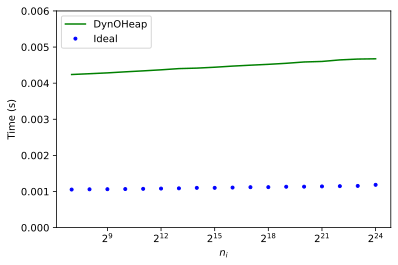

In [127]:
plt.plot(dyn_heap['n'], networked_delete(dyn_heap), label='DynOHeap', linestyle='-', color='green')
plt.plot(stt_heap['n'], networked_delete(stt_heap), label='Ideal', linestyle='', color='blue', marker='.')

plt.xlabel('$n_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.ylim(0.0, 0.006)
# plt.yscale('log')
plt.legend(loc='upper left')
plt.savefig('plots/final/dynoheap_delete.eps')
plt.show()

In [36]:
dyn_heap

,n,alloc,insert,insert_accesses,insert_bytes,delete,delete_accesses,delete_bytes
6,128,0.000027,0.000310,25,29680,0.000222,20,23744
7,256,0.000045,0.000382,25,33040,0.000242,20,26432
8,512,0.000102,0.000504,25,36400,0.000263,20,29120
9,1024,0.000192,0.000693,25,39760,0.000290,20,31808
10,2048,0.000407,0.001090,25,43120,0.000315,20,34496
11,4096,0.000813,0.001943,25,46480,0.000342,20,37184
12,8192,0.001683,0.003474,25,49840,0.000374,20,39872
13,16384,0.003396,0.006596,25,53200,0.000385,20,42560
14,32768,0.006749,0.012666,25,56560,0.000408,20,45248
15,65536,0.013477,0.024875,25,59920,0.000437,20,47936
